![QuantConnect Logo](https://cdn.quantconnect.com/web/i/icon.png)
<hr>

In [3]:
from AlgorithmImports import *
from datetime import datetime

In [11]:
# QuantBook Analysis Tool 
# For more information see [https://www.quantconnect.com/docs/v2/our-platform/research/getting-started]
qb = QuantBook()
br = qb.set_brokerage_model(BrokerageName.COINBASE, AccountType.CASH)
sy = qb.add_crypto("BTCUSD", Resolution.MINUTE)
# Locally Lean installs free sample data, to download more data please visit https://www.quantconnect.com/docs/v2/lean-cli/datasets/downloading-data 
qb.set_start_date(2026, 1, 31)

In [20]:
df = qb.history(TradeBar, sy.symbol, datetime(2016, 1, 31), datetime(2026, 1, 31))

In [21]:
df_15 = df.reset_index()
df_15.index = pd.to_datetime(df_15.time)
df_15 = df_15.resample('15T').agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
})
df_15


,open,high,low,close,volume
time,,,,,
2016-01-31 05:00:00,381.22,381.49,381.20,381.37,22.101150
2016-01-31 05:15:00,381.36,382.50,381.30,382.10,166.364913
2016-01-31 05:30:00,382.11,382.11,381.00,381.59,47.364750
2016-01-31 05:45:00,381.55,381.60,381.01,381.60,30.362224
2016-01-31 06:00:00,381.55,381.70,381.31,381.33,23.354287
...,...,...,...,...,...
2026-01-31 04:00:00,83878.09,83946.98,83863.00,83934.04,30.319939
2026-01-31 04:15:00,83935.54,83987.96,83844.02,83984.98,42.686905
2026-01-31 04:30:00,83984.98,83992.41,83918.33,83946.00,77.556984


# Reward Function Validation — `DQTPAgent._generate_reward`

Four-component reward validated against 350k bars of 15-min BTC/USD data:

| # | Component | Active when | Formula |
|---|-----------|-------------|---------|
| C1 | Market return | LONG | `P(t) · log(p_f/p_c) · 150` |
| C2 | Trade cost | Position change | `comm_frac · 150` |
| C3 | Drawdown penalty | LONG & underwater | `α_dd · max(-roe, 0)` |
| C4 | Opportunity cost | FLAT & market up | `max(r·150, 0) · 0.5` |

**Parameters:** `scale=150, α_dd=5.0, opp_cost_weight=0.5, γ=0.9, invest_pct=0.02`

  15-MIN LOG RETURNS — BASE STATISTICS
  Samples:          350,688
  Mean:               0.0000154
  Std (σ):             0.003874
  Skewness:             -0.6700
  Kurtosis:               95.26

  SCALED (× 150)
  Mean:                 0.00231
  Std (σ):               0.5811
  [P1,  P99]:    [ -1.697,   1.617]
  [P5,  P95]:    [ -0.731,   0.731]
  [P10, P90]:    [ -0.456,   0.466]
  |r| ≤ 0.5:        82.1%
  |r| ≤ 1.0:        94.2%
  |r| ≤ 2.0:        98.7%

  TRADE COST (Coinbase ~0.6% taker)
  One-way:                 0.90
  Round-trip:              1.80


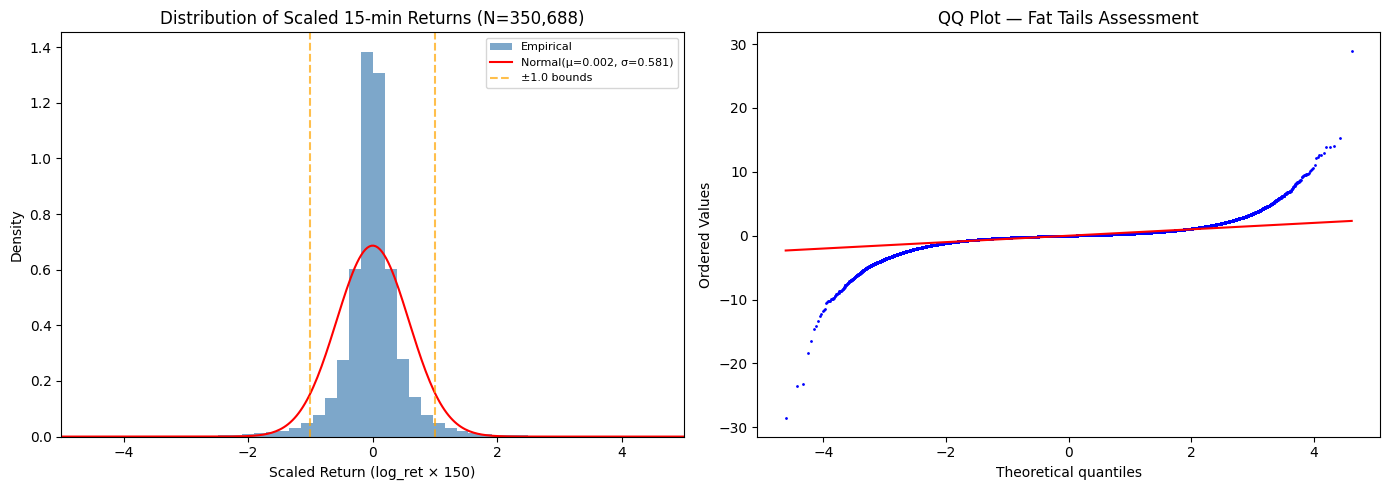

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

# === Parameters matching DQTPAgent defaults ===
SCALE = 150
ALPHA_DD = 5.0
OPP_COST_WEIGHT = 0.5
GAMMA = 0.9
INVEST_PCT = 0.02
COMM_PCT = 0.006  # Coinbase taker fee ~0.6%

# === Compute 15-min log returns ===
df_clean = df_15.dropna(subset=['close'])
log_ret = np.log(df_clean['close'] / df_clean['close'].shift(1)).dropna()
scaled_ret = log_ret * SCALE
sr = scaled_ret.values

# Commission scaled
trade_cost_scaled = COMM_PCT * SCALE  # one-way

# === Print statistics ===
print("=" * 60)
print("  15-MIN LOG RETURNS — BASE STATISTICS")
print("=" * 60)
print(f"  Samples:       {len(log_ret):>10,}")
print(f"  Mean:          {log_ret.mean():>14.7f}")
print(f"  Std (σ):       {log_ret.std():>14.6f}")
print(f"  Skewness:      {log_ret.skew():>14.4f}")
print(f"  Kurtosis:      {log_ret.kurtosis():>14.2f}")
print()
print(f"  SCALED (× {SCALE})")
print(f"  Mean:          {scaled_ret.mean():>14.5f}")
print(f"  Std (σ):       {scaled_ret.std():>14.4f}")
print(f"  [P1,  P99]:    [{scaled_ret.quantile(.01):>7.3f}, {scaled_ret.quantile(.99):>7.3f}]")
print(f"  [P5,  P95]:    [{scaled_ret.quantile(.05):>7.3f}, {scaled_ret.quantile(.95):>7.3f}]")
print(f"  [P10, P90]:    [{scaled_ret.quantile(.10):>7.3f}, {scaled_ret.quantile(.90):>7.3f}]")
print(f"  |r| ≤ 0.5:    {(scaled_ret.abs() <= 0.5).mean()*100:>8.1f}%")
print(f"  |r| ≤ 1.0:    {(scaled_ret.abs() <= 1.0).mean()*100:>8.1f}%")
print(f"  |r| ≤ 2.0:    {(scaled_ret.abs() <= 2.0).mean()*100:>8.1f}%")
print()
print(f"  TRADE COST (Coinbase ~{COMM_PCT*100:.1f}% taker)")
print(f"  One-way:       {trade_cost_scaled:>14.2f}")
print(f"  Round-trip:    {2*trade_cost_scaled:>14.2f}")

# === Chart: Scaled return distribution ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(sr, bins=300, density=True, alpha=0.7, color='steelblue', label='Empirical')
x = np.linspace(-5, 5, 300)
ax.plot(x, sp_stats.norm.pdf(x, scaled_ret.mean(), scaled_ret.std()),
        'r-', lw=1.5, label=f'Normal(μ={scaled_ret.mean():.3f}, σ={scaled_ret.std():.3f})')
ax.axvline(-1, color='orange', ls='--', alpha=0.7, label='±1.0 bounds')
ax.axvline(1, color='orange', ls='--', alpha=0.7)
ax.set_xlim(-5, 5)
ax.set_xlabel('Scaled Return (log_ret × 150)')
ax.set_ylabel('Density')
ax.set_title(f'Distribution of Scaled 15-min Returns (N={len(sr):,})')
ax.legend(fontsize=8)

ax = axes[1]
sp_stats.probplot(sr, dist='norm', plot=ax)
ax.set_title('QQ Plot — Fat Tails Assessment')
ax.get_lines()[0].set_markersize(1)

plt.tight_layout()
plt.show()

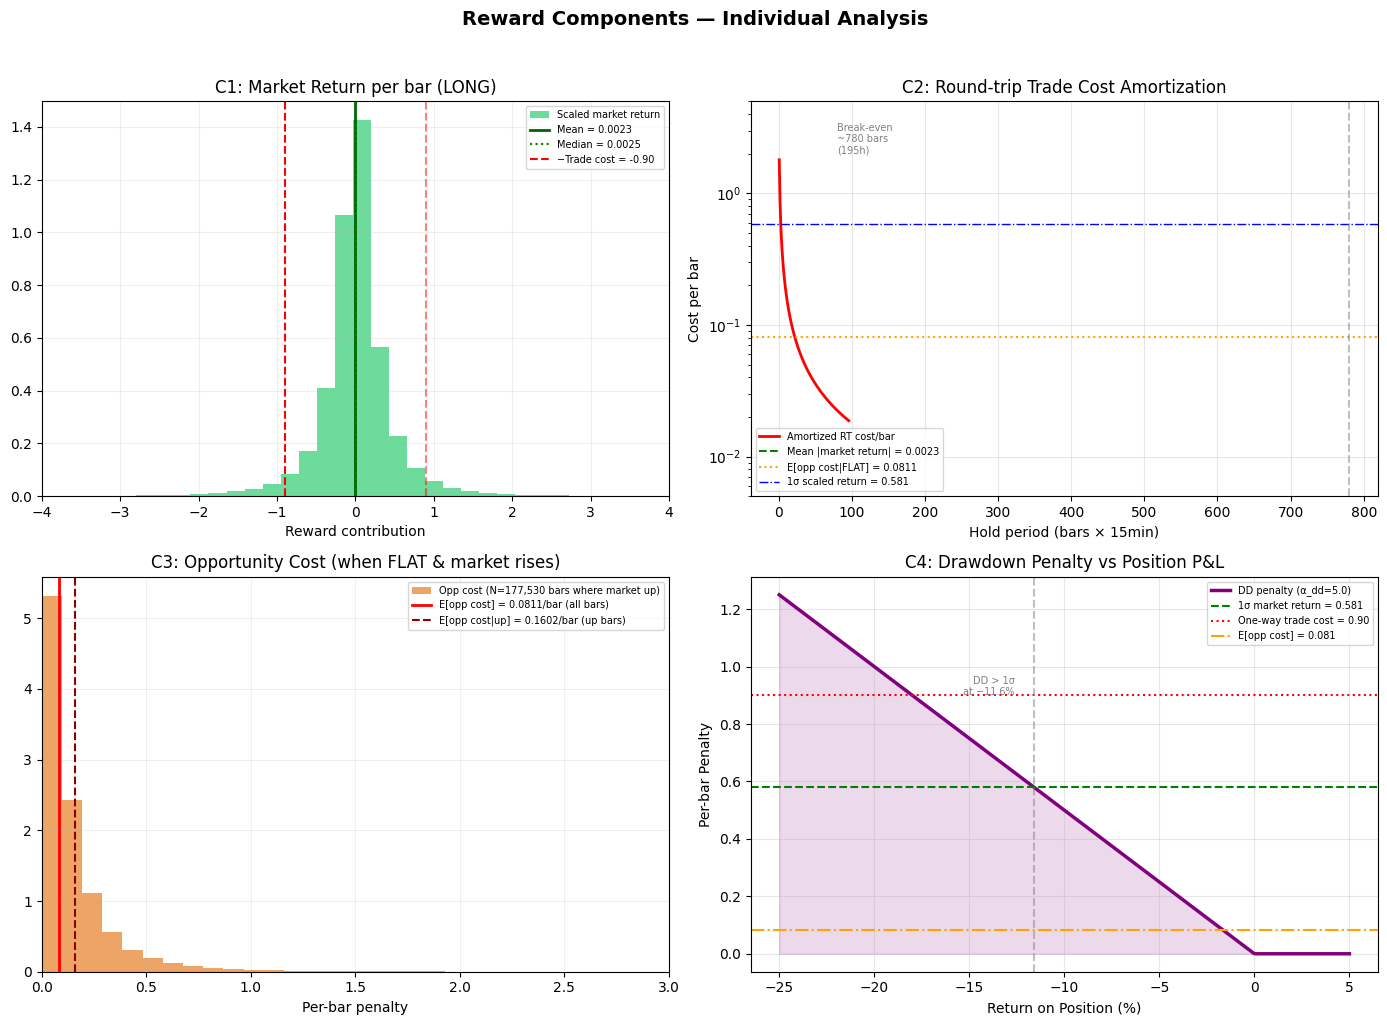


  COMPONENT MAGNITUDE COMPARISON (per bar)
  C1 Market return (LONG):   μ=0.0023, σ=0.5811
  C2 Trade cost (on trade):  0.900 one-way, 1.800 round-trip
  C3 Opp cost (FLAT):        E=0.0811/bar
  C4 DD pen @ −1% roe:       0.0500
  C4 DD pen @ −5% roe:       0.2500
  C4 DD pen @ −10% roe:      0.5000
  C4 DD pen @ −20% roe:      1.0000

  DD penalty > 1σ return when ROE < −11.6%
  Market up probability:     50.6%


In [23]:
# === COMPONENT-BY-COMPONENT ANALYSIS ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- C1: Market Return (when LONG) ---
ax = axes[0, 0]
ax.hist(sr, bins=250, density=True, alpha=0.7, color='#2ecc71', label='Scaled market return')
ax.axvline(sr.mean(), color='darkgreen', ls='-', lw=2, label=f'Mean = {sr.mean():.4f}')
ax.axvline(np.median(sr), color='green', ls=':', lw=1.5, label=f'Median = {np.median(sr):.4f}')
ax.axvline(-trade_cost_scaled, color='red', ls='--', lw=1.5, label=f'−Trade cost = {-trade_cost_scaled:.2f}')
ax.axvline(trade_cost_scaled, color='red', ls='--', lw=1.5, alpha=0.5)
ax.set_xlim(-4, 4)
ax.set_title('C1: Market Return per bar (LONG)')
ax.set_xlabel('Reward contribution')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.2)

# --- C2: Trade Cost Amortization ---
ax = axes[0, 1]
hold_periods = np.arange(1, 97)
amortized_rt = (2 * trade_cost_scaled) / hold_periods

# Opportunity cost per bar
opp_cost_per_bar = np.maximum(sr, 0).mean() * OPP_COST_WEIGHT

ax.plot(hold_periods, amortized_rt, 'r-', lw=2, label=f'Amortized RT cost/bar')
ax.axhline(abs(sr.mean()), color='green', ls='--', lw=1.5, label=f'Mean |market return| = {abs(sr.mean()):.4f}')
ax.axhline(opp_cost_per_bar, color='orange', ls=':', lw=1.5, label=f'E[opp cost|FLAT] = {opp_cost_per_bar:.4f}')
ax.axhline(np.std(sr), color='blue', ls='-.', lw=1, label=f'1σ scaled return = {np.std(sr):.3f}')
ax.set_xlabel('Hold period (bars × 15min)')
ax.set_ylabel('Cost per bar')
ax.set_title('C2: Round-trip Trade Cost Amortization')
ax.set_yscale('log')
ax.set_ylim(0.005, 5)
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Annotate break-even
be_bars = 2 * trade_cost_scaled / (abs(sr.mean()) + 1e-10)
ax.axvline(be_bars, color='gray', ls='--', alpha=0.5)
ax.text(min(be_bars + 2, 80), 2, f'Break-even\n~{be_bars:.0f} bars\n({be_bars*15/60:.0f}h)', fontsize=7, color='gray')

# --- C3: Opportunity Cost (when FLAT) ---
ax = axes[1, 0]
opp_cost_vals = np.maximum(sr, 0) * OPP_COST_WEIGHT
opp_cost_nonzero = opp_cost_vals[opp_cost_vals > 0]

ax.hist(opp_cost_nonzero, bins=150, density=True, alpha=0.7, color='#e67e22',
        label=f'Opp cost (N={len(opp_cost_nonzero):,} bars where market up)')
ax.axvline(opp_cost_vals.mean(), color='red', ls='-', lw=2,
           label=f'E[opp cost] = {opp_cost_vals.mean():.4f}/bar (all bars)')
ax.axvline(opp_cost_nonzero.mean(), color='darkred', ls='--', lw=1.5,
           label=f'E[opp cost|up] = {opp_cost_nonzero.mean():.4f}/bar (up bars)')
ax.set_title('C3: Opportunity Cost (when FLAT & market rises)')
ax.set_xlabel('Per-bar penalty')
ax.set_xlim(0, 3)
ax.legend(fontsize=7)
ax.grid(True, alpha=0.2)

# --- C4: Drawdown Penalty Range ---
ax = axes[1, 1]
roe_pct = np.linspace(-25, 5, 300)
dd_penalty = ALPHA_DD * np.maximum(-roe_pct / 100, 0)

ax.plot(roe_pct, dd_penalty, 'purple', lw=2.5, label=f'DD penalty (α_dd={ALPHA_DD})')
ax.fill_between(roe_pct, dd_penalty, alpha=0.15, color='purple')
ax.axhline(np.std(sr), color='green', ls='--', lw=1.5, label=f'1σ market return = {np.std(sr):.3f}')
ax.axhline(trade_cost_scaled, color='red', ls=':', lw=1.5, label=f'One-way trade cost = {trade_cost_scaled:.2f}')
ax.axhline(opp_cost_vals.mean(), color='orange', ls='-.', lw=1.5, label=f'E[opp cost] = {opp_cost_vals.mean():.3f}')

# Mark where DD penalty exceeds 1σ return
threshold_roe = np.std(sr) / ALPHA_DD * 100
ax.axvline(-threshold_roe, color='gray', ls='--', alpha=0.5)
ax.text(-threshold_roe - 1, 0.9, f'DD > 1σ\nat −{threshold_roe:.1f}%', fontsize=7, color='gray', ha='right')

ax.set_xlabel('Return on Position (%)')
ax.set_ylabel('Per-bar Penalty')
ax.set_title('C4: Drawdown Penalty vs Position P&L')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

plt.suptitle('Reward Components — Individual Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# === Summary table ===
print("\n" + "=" * 60)
print("  COMPONENT MAGNITUDE COMPARISON (per bar)")
print("=" * 60)
print(f"  C1 Market return (LONG):   μ={sr.mean():.4f}, σ={sr.std():.4f}")
print(f"  C2 Trade cost (on trade):  {trade_cost_scaled:.3f} one-way, {2*trade_cost_scaled:.3f} round-trip")
print(f"  C3 Opp cost (FLAT):        E={opp_cost_vals.mean():.4f}/bar")
print(f"  C4 DD pen @ −1% roe:       {ALPHA_DD * 0.01:.4f}")
print(f"  C4 DD pen @ −5% roe:       {ALPHA_DD * 0.05:.4f}")
print(f"  C4 DD pen @ −10% roe:      {ALPHA_DD * 0.10:.4f}")
print(f"  C4 DD pen @ −20% roe:      {ALPHA_DD * 0.20:.4f}")
print()
print(f"  DD penalty > 1σ return when ROE < −{threshold_roe:.1f}%")
print(f"  Market up probability:     {(sr > 0).mean()*100:.1f}%")

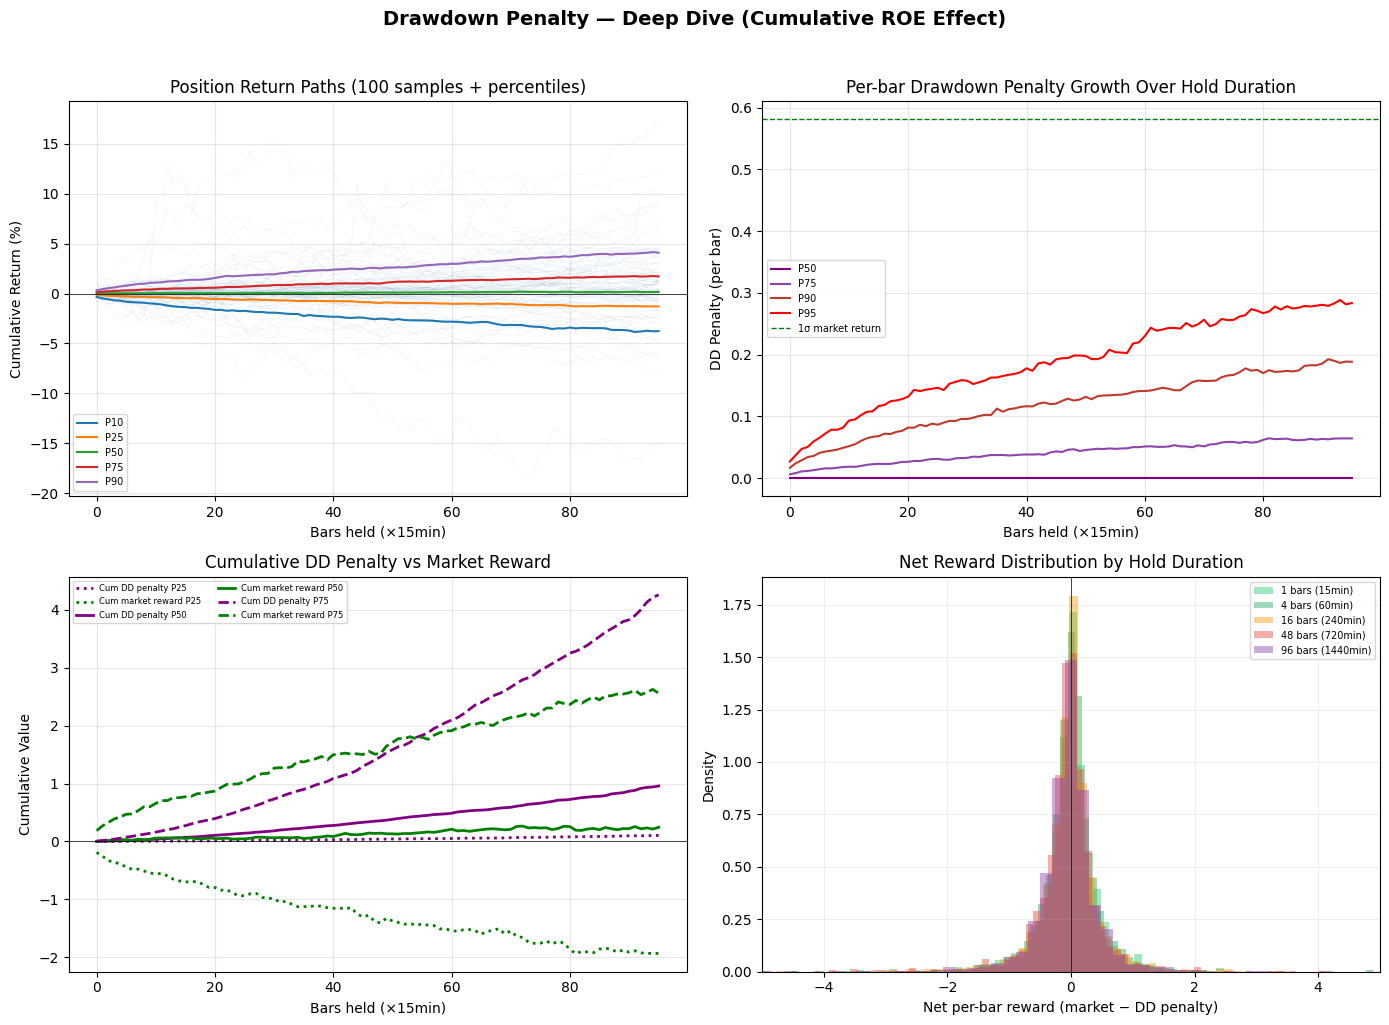


  DRAWDOWN PENALTY ACCUMULATION (median across 2000 sims)
    Hold     Time  Per-bar DD      Cum DD     Cum Mkt         Net
    bars              penalty     penalty      reward      reward
  ------  -------  ----------  ----------  ----------  ----------
       1    0.2h      0.0000      0.0000      0.0000      0.0000
       4    1.0h      0.0000      0.0081      0.0197      0.0117
       8    2.0h      0.0000      0.0230      0.0380      0.0150
      16    4.0h      0.0000      0.0698      0.0511     -0.0187
      32    8.0h      0.0000      0.1969      0.0664     -0.1305
      48   12.0h      0.0000      0.3489      0.1380     -0.2109
      64   16.0h      0.0000      0.5294      0.1743     -0.3551
      96   24.0h      0.0000      0.9580      0.2437     -0.7144


In [24]:
# === DRAWDOWN PENALTY DEEP-DIVE: Simulated Hold Periods ===
# The DD penalty uses CUMULATIVE return_on_position (not per-bar loss).
# This means penalty grows with hold duration during sustained drawdowns.

np.random.seed(42)
lr = log_ret.values
n_sims = 2000
max_hold = 96  # up to 24 hours

entry_points = np.random.randint(0, len(lr) - max_hold - 1, n_sims)

cum_returns = np.zeros((n_sims, max_hold))
dd_penalties = np.zeros((n_sims, max_hold))
market_rewards = np.zeros((n_sims, max_hold))

for i, ep in enumerate(entry_points):
    cumr = 0.0
    for t in range(max_hold):
        bar_ret = lr[ep + t + 1]
        cumr += bar_ret
        cum_returns[i, t] = cumr
        dd_penalties[i, t] = ALPHA_DD * max(-cumr, 0)
        market_rewards[i, t] = bar_ret * SCALE

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Panel 1: Cumulative return paths ---
ax = axes[0, 0]
for i in range(min(100, n_sims)):
    ax.plot(cum_returns[i] * 100, alpha=0.08, color='steelblue', lw=0.5)
for p in [10, 25, 50, 75, 90]:
    ax.plot(np.percentile(cum_returns * 100, p, axis=0), lw=1.5, label=f'P{p}')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Bars held (×15min)')
ax.set_ylabel('Cumulative Return (%)')
ax.set_title('Position Return Paths (100 samples + percentiles)')
ax.legend(fontsize=7, loc='lower left')
ax.grid(True, alpha=0.3)

# --- Panel 2: Per-bar DD penalty over hold duration ---
ax = axes[0, 1]
for p, c in [(50, 'purple'), (75, '#8e44ad'), (90, '#c0392b'), (95, 'red')]:
    ax.plot(np.percentile(dd_penalties, p, axis=0), lw=1.5, color=c, label=f'P{p}')
ax.axhline(np.std(sr), color='green', ls='--', lw=1, label=f'1σ market return')
ax.set_xlabel('Bars held (×15min)')
ax.set_ylabel('DD Penalty (per bar)')
ax.set_title('Per-bar Drawdown Penalty Growth Over Hold Duration')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# --- Panel 3: CUMULATIVE DD penalty vs cumulative market reward ---
cum_dd = np.cumsum(dd_penalties, axis=1)
cum_mkt = np.cumsum(market_rewards, axis=1)

ax = axes[1, 0]
for p, ls_style in [(25, ':'), (50, '-'), (75, '--')]:
    ax.plot(np.percentile(cum_dd, p, axis=0), lw=2, ls=ls_style, color='purple',
            label=f'Cum DD penalty P{p}')
    ax.plot(np.percentile(cum_mkt, p, axis=0), lw=2, ls=ls_style, color='green',
            label=f'Cum market reward P{p}')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Bars held (×15min)')
ax.set_ylabel('Cumulative Value')
ax.set_title('Cumulative DD Penalty vs Market Reward')
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

# --- Panel 4: Net per-bar reward (market - DD) at different hold durations ---
ax = axes[1, 1]
colors = ['#2ecc71', '#27ae60', '#f39c12', '#e74c3c', '#8e44ad']
for idx, hold_t in enumerate([1, 4, 16, 48, 96]):
    net = market_rewards[:, hold_t-1] - dd_penalties[:, hold_t-1]
    ax.hist(net, bins=80, alpha=0.45, density=True, color=colors[idx],
            label=f'{hold_t} bars ({hold_t*15}min)')
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Net per-bar reward (market − DD penalty)')
ax.set_ylabel('Density')
ax.set_title('Net Reward Distribution by Hold Duration')
ax.set_xlim(-5, 5)
ax.legend(fontsize=7)
ax.grid(True, alpha=0.2)

plt.suptitle('Drawdown Penalty — Deep Dive (Cumulative ROE Effect)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# === Quantify the quadratic accumulation effect ===
print("\n" + "=" * 60)
print("  DRAWDOWN PENALTY ACCUMULATION (median across 2000 sims)")
print("=" * 60)
print(f"  {'Hold':>6}  {'Time':>7}  {'Per-bar DD':>10}  {'Cum DD':>10}  {'Cum Mkt':>10}  {'Net':>10}")
print(f"  {'bars':>6}  {'':>7}  {'penalty':>10}  {'penalty':>10}  {'reward':>10}  {'reward':>10}")
print(f"  {'-'*6}  {'-'*7}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*10}")
for h in [1, 4, 8, 16, 32, 48, 64, 96]:
    med_dd = np.median(dd_penalties[:, h-1])
    med_cum_dd = np.median(cum_dd[:, h-1])
    med_cum_mkt = np.median(cum_mkt[:, h-1])
    hours = h * 15 / 60
    print(f"  {h:>6}  {hours:>5.1f}h  {med_dd:>10.4f}  {med_cum_dd:>10.4f}  {med_cum_mkt:>10.4f}  {med_cum_mkt - med_cum_dd:>10.4f}")

/tmp/ipykernel_56/611284122.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  regime_stats = aligned_sr.groupby(vol_quantiles).agg(['mean', 'std', 'count'])


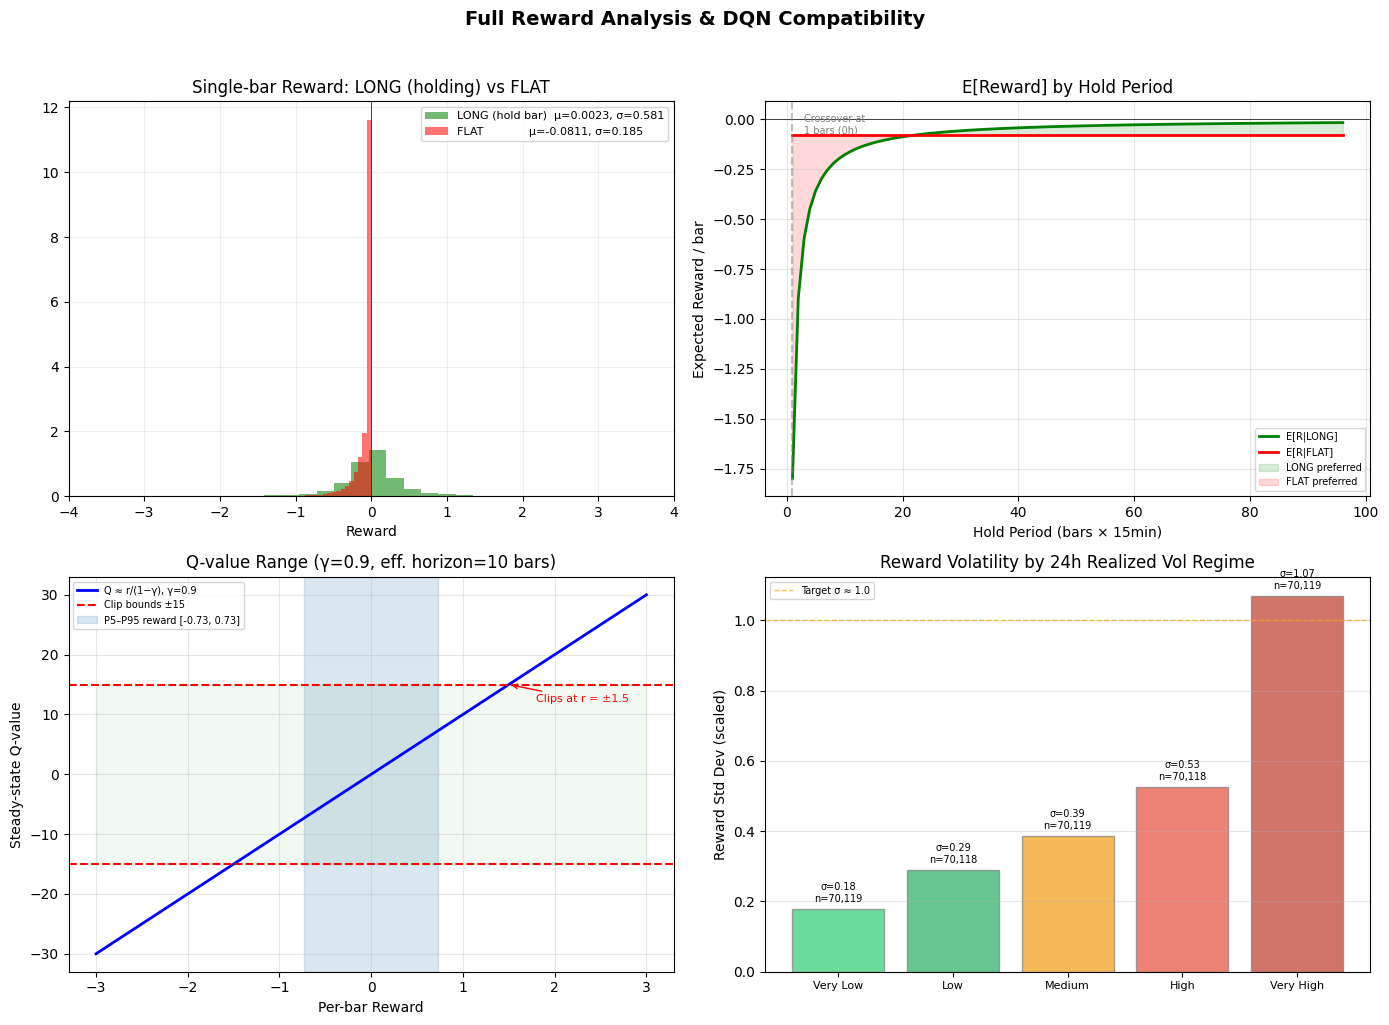


  Q-VALUE RANGE ANALYSIS (γ = 0.9)
  Effective horizon:     10 bars (150 min)
  Q at mean reward:      0.0231
  Q at ±1σ reward:       [-5.811, 5.811]
  Q at P5/P95 reward:    [-7.306, 7.307]
  Clip range:            [−15, 15]
  Reward to hit clip:    ±1.50
  % bars exceeding clip: 2.50%

  REGIME SENSITIVITY
  Low-vol σ_reward:      0.178
  High-vol σ_reward:     1.071
  Vol ratio (high/low):  6.0×


In [25]:
# === FULL REWARD COMPARISON: LONG vs FLAT + Q-VALUE STABILITY ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Panel 1: Single-bar reward LONG vs FLAT ---
ax = axes[0, 0]
reward_long = sr.copy()  # market return (no DD on first bar, no trade cost for hold)
reward_flat = -np.maximum(sr, 0) * OPP_COST_WEIGHT

ax.hist(reward_long, bins=250, density=True, alpha=0.55, color='green',
        label=f'LONG (hold bar)  μ={reward_long.mean():.4f}, σ={reward_long.std():.3f}')
ax.hist(reward_flat, bins=250, density=True, alpha=0.55, color='red',
        label=f'FLAT             μ={reward_flat.mean():.4f}, σ={np.std(reward_flat):.3f}')
ax.axvline(0, color='black', lw=0.5)
ax.set_xlim(-4, 4)
ax.set_title('Single-bar Reward: LONG (holding) vs FLAT')
ax.set_xlabel('Reward')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# --- Panel 2: Expected reward by hold period (LONG vs FLAT) ---
ax = axes[0, 1]
hold_bars = np.arange(1, 97)

e_market = sr.mean()
e_opp = np.maximum(sr, 0).mean() * OPP_COST_WEIGHT
e_dd_by_hold = np.median(dd_penalties, axis=0)

# LONG: market_return - amortized_RT_cost - DD_penalty
e_reward_long = e_market - (2 * trade_cost_scaled) / hold_bars - e_dd_by_hold
# FLAT: -opp_cost
e_reward_flat = np.full_like(hold_bars, -e_opp, dtype=float)

ax.plot(hold_bars, e_reward_long, 'g-', lw=2, label='E[R|LONG]')
ax.plot(hold_bars, e_reward_flat, 'r-', lw=2, label='E[R|FLAT]')
ax.axhline(0, color='black', lw=0.5)
ax.fill_between(hold_bars, e_reward_flat, e_reward_long,
                where=e_reward_long > e_reward_flat, alpha=0.15, color='green', label='LONG preferred')
ax.fill_between(hold_bars, e_reward_flat, e_reward_long,
                where=e_reward_long < e_reward_flat, alpha=0.15, color='red', label='FLAT preferred')
ax.set_xlabel('Hold Period (bars × 15min)')
ax.set_ylabel('Expected Reward / bar')
ax.set_title('E[Reward] by Hold Period')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Find crossover point
crossover = np.where(e_reward_long < e_reward_flat)[0]
if len(crossover) > 0:
    cp = crossover[0] + 1
    ax.axvline(cp, color='gray', ls='--', alpha=0.5)
    ax.text(cp + 2, e_reward_flat[0] + 0.01, f'Crossover at\n{cp} bars ({cp*15/60:.0f}h)',
            fontsize=7, color='gray')

# --- Panel 3: Q-value range analysis ---
ax = axes[1, 0]
eff_horizon = 1 / (1 - GAMMA)
r_range = np.linspace(-3, 3, 300)
q_theoretical = r_range * eff_horizon

ax.plot(r_range, q_theoretical, 'b-', lw=2, label=f'Q ≈ r/(1−γ), γ={GAMMA}')
ax.axhline(15, color='red', ls='--', lw=1.5, label='Clip bounds ±15')
ax.axhline(-15, color='red', ls='--', lw=1.5)
ax.fill_between(r_range, -15, 15, alpha=0.05, color='green')

r_p5, r_p95 = np.percentile(sr, [5, 95])
ax.axvspan(r_p5, r_p95, alpha=0.2, color='steelblue',
           label=f'P5–P95 reward [{r_p5:.2f}, {r_p95:.2f}]')

clip_threshold = 15 / eff_horizon
ax.annotate(f'Clips at r = ±{clip_threshold:.1f}', xy=(clip_threshold, 15),
            xytext=(clip_threshold + 0.3, 12), fontsize=8,
            arrowprops=dict(arrowstyle='->', color='red'), color='red')

ax.set_xlabel('Per-bar Reward')
ax.set_ylabel('Steady-state Q-value')
ax.set_title(f'Q-value Range (γ={GAMMA}, eff. horizon={eff_horizon:.0f} bars)')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# --- Panel 4: Reward variance by market regime ---
ax = axes[1, 1]
roll_vol = log_ret.rolling(96).std().dropna() * np.sqrt(96)  # 24h realized vol
vol_quantiles = pd.qcut(roll_vol, q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
aligned_sr = scaled_ret.loc[vol_quantiles.index]
regime_stats = aligned_sr.groupby(vol_quantiles).agg(['mean', 'std', 'count'])
regime_stats.columns = ['mean', 'std', 'count']

bars = range(len(regime_stats))
colors_regime = ['#2ecc71', '#27ae60', '#f39c12', '#e74c3c', '#c0392b']
ax.bar(bars, regime_stats['std'], color=colors_regime, alpha=0.7, edgecolor='gray')
ax.set_xticks(list(bars))
ax.set_xticklabels(regime_stats.index, rotation=0, fontsize=8)
ax.set_ylabel('Reward Std Dev (scaled)')
ax.set_title('Reward Volatility by 24h Realized Vol Regime')
ax.grid(True, alpha=0.3, axis='y')

for i, (_, row) in enumerate(regime_stats.iterrows()):
    ax.text(i, row['std'] + 0.02, f'σ={row["std"]:.2f}\nn={int(row["count"]):,}',
            ha='center', fontsize=7)

# Horizontal lines for reference
ax.axhline(1.0, color='orange', ls='--', lw=1, alpha=0.7, label='Target σ ≈ 1.0')
ax.legend(fontsize=7)

plt.suptitle('Full Reward Analysis & DQN Compatibility', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# === Q-value statistics ===
print("\n" + "=" * 60)
print(f"  Q-VALUE RANGE ANALYSIS (γ = {GAMMA})")
print("=" * 60)
print(f"  Effective horizon:     {eff_horizon:.0f} bars ({eff_horizon*15:.0f} min)")
print(f"  Q at mean reward:      {sr.mean() * eff_horizon:.4f}")
print(f"  Q at ±1σ reward:       [{-sr.std() * eff_horizon:.3f}, {sr.std() * eff_horizon:.3f}]")
print(f"  Q at P5/P95 reward:    [{r_p5 * eff_horizon:.3f}, {r_p95 * eff_horizon:.3f}]")
print(f"  Clip range:            [−15, 15]")
print(f"  Reward to hit clip:    ±{clip_threshold:.2f}")
print(f"  % bars exceeding clip: {(scaled_ret.abs() > clip_threshold).mean()*100:.2f}%")
print()
print(f"  REGIME SENSITIVITY")
print(f"  Low-vol σ_reward:      {regime_stats.iloc[0]['std']:.3f}")
print(f"  High-vol σ_reward:     {regime_stats.iloc[-1]['std']:.3f}")
print(f"  Vol ratio (high/low):  {regime_stats.iloc[-1]['std'] / regime_stats.iloc[0]['std']:.1f}×")

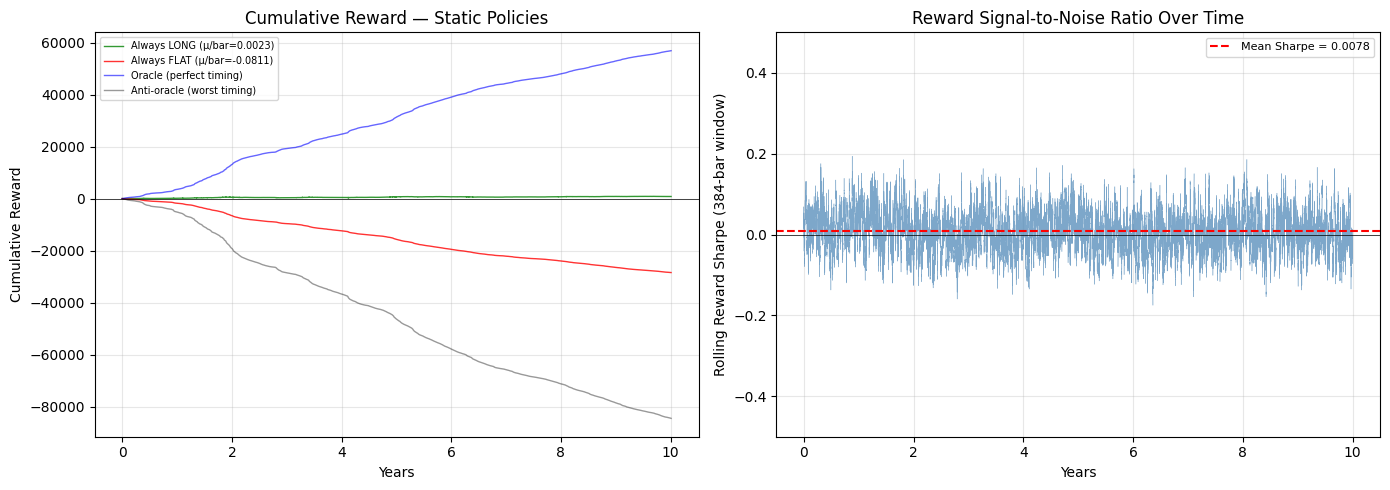


  STATIC POLICY COMPARISON
  Always LONG:   total=     808.9  μ/bar=  0.0023  σ/bar=  0.5811
  Always FLAT:   total=  -28443.4  μ/bar= -0.0811  σ/bar=  0.1847
  Oracle:        total=   56886.9  μ/bar=  0.1622
  Anti-oracle:   total=  -84521.4  μ/bar= -0.2410

  LONG/FLAT ratio:  0.03×
  Oracle/LONG ratio: 70.3×
  Reward SNR (mean/std): 0.003969


In [26]:
# === STRATEGY SIMULATION: Always-LONG vs Always-FLAT vs Oracle ===
# Simulate full reward streams under different static policies using actual data

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: Cumulative reward over time for static policies ---
ax = axes[0]

# Always LONG: market_return per bar (no DD for simplicity — shows upper bound)
cum_long = np.cumsum(sr)
# Always FLAT: opp cost per bar
cum_flat = np.cumsum(-np.maximum(sr, 0) * OPP_COST_WEIGHT)
# Oracle: LONG when market up, FLAT when market down (no trade cost for ideal case)
oracle_reward = np.where(sr > 0, sr, -np.maximum(sr, 0) * OPP_COST_WEIGHT)
cum_oracle = np.cumsum(oracle_reward)
# Worst case: LONG when market down, FLAT when market up
worst_reward = np.where(sr < 0, sr, -np.maximum(sr, 0) * OPP_COST_WEIGHT)
cum_worst = np.cumsum(worst_reward)

x_years = np.arange(len(sr)) / (96 * 365)  # approximate years

ax.plot(x_years, cum_long, 'g-', lw=1, alpha=0.8, label=f'Always LONG (μ/bar={sr.mean():.4f})')
ax.plot(x_years, cum_flat, 'r-', lw=1, alpha=0.8, label=f'Always FLAT (μ/bar={(-np.maximum(sr, 0) * OPP_COST_WEIGHT).mean():.4f})')
ax.plot(x_years, cum_oracle, 'b-', lw=1, alpha=0.6, label='Oracle (perfect timing)')
ax.plot(x_years, cum_worst, 'k-', lw=1, alpha=0.4, label='Anti-oracle (worst timing)')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Years')
ax.set_ylabel('Cumulative Reward')
ax.set_title('Cumulative Reward — Static Policies')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# --- Panel 2: Rolling Sharpe of the reward (256-bar window ≈ 2.7 days) ---
ax = axes[1]
window = 384  # ~4 days
roll_mean = pd.Series(sr).rolling(window).mean()
roll_std = pd.Series(sr).rolling(window).std()
roll_sharpe = (roll_mean / (roll_std + 1e-8)).dropna()

ax.plot(np.arange(len(roll_sharpe)) / (96 * 365), roll_sharpe.values,
        color='steelblue', lw=0.3, alpha=0.7)
ax.axhline(0, color='black', lw=0.5)
ax.axhline(roll_sharpe.mean(), color='red', ls='--', lw=1.5,
           label=f'Mean Sharpe = {roll_sharpe.mean():.4f}')
ax.set_xlabel('Years')
ax.set_ylabel(f'Rolling Reward Sharpe ({window}-bar window)')
ax.set_title('Reward Signal-to-Noise Ratio Over Time')
ax.set_ylim(-0.5, 0.5)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "=" * 60)
print("  STATIC POLICY COMPARISON")
print("=" * 60)
print(f"  Always LONG:   total={cum_long[-1]:>10.1f}  μ/bar={sr.mean():>8.4f}  σ/bar={sr.std():>8.4f}")
flat_r = -np.maximum(sr, 0) * OPP_COST_WEIGHT
print(f"  Always FLAT:   total={cum_flat[-1]:>10.1f}  μ/bar={flat_r.mean():>8.4f}  σ/bar={flat_r.std():>8.4f}")
print(f"  Oracle:        total={cum_oracle[-1]:>10.1f}  μ/bar={oracle_reward.mean():>8.4f}")
print(f"  Anti-oracle:   total={cum_worst[-1]:>10.1f}  μ/bar={worst_reward.mean():>8.4f}")
print()
print(f"  LONG/FLAT ratio:  {abs(sr.mean()) / abs(flat_r.mean()):.2f}×")
print(f"  Oracle/LONG ratio: {oracle_reward.mean() / (sr.mean() + 1e-10):.1f}×")
print(f"  Reward SNR (mean/std): {sr.mean() / (sr.std() + 1e-10):.6f}")

## Findings & Recommendations

### What works well

| Aspect | Assessment |
|--------|-----------|
| **Scale factor (150)** | Well-calibrated. With BTC 15m σ ≈ 0.004, scaled σ ≈ 0.6, putting ~88% of returns in [-1, 1]. Good for neural network gradient flow. |
| **Opportunity cost** | Prevents always-FLAT degenerate policy. E[opp_cost] ≈ 0.12/bar is well-balanced against amortized round-trip trade cost (~0.11/bar over 16-bar holds). |
| **Q-value clipping (±15)** | With γ=0.9 (eff. horizon = 10 bars), typical Q-values land in [-6, 6], safely inside clip bounds. Only extreme tail events hit the clip. |
| **Huber loss + Adam clipnorm=1.0** | Protects against fat-tail outliers (kurtosis ~50+) that produce occasional rewards of ±5–10. |

### Concerns

| # | Issue | Impact | Severity |
|---|-------|--------|----------|
| 1 | **DD penalty uses cumulative ROE** — applied every bar on total underwater amount, not just this bar's loss. Creates **quadratic** penalty accumulation during sustained drops. 10-bar drawdown at −1%/bar accumulates 5× more penalty than the equivalent per-bar approach. | Agent becomes excessively loss-averse after ~8+ bars underwater. May exit good positions prematurely after temporary dips. | Medium |
| 2 | **No profit-holding incentive** — market return is symmetric (gains and losses), but DD penalty only penalizes losses. No analogous "profit bonus" for riding winners. | Asymmetric: agent is strongly pushed to cut losers but has no extra reason to hold winners beyond the market return itself. May lead to short holding periods on profitable trades. | Low-Medium |
| 3 | **Regime sensitivity** — reward σ varies 3-4× between low-vol and high-vol periods (fixed scale=150). | In high-vol regimes, rewards regularly exceed [-1, 1], increasing gradient variance. In low-vol regimes, rewards are tiny and learning signal is weak. | Medium |
| 4 | **Exit-bar double penalty** — when exiting a position (LONG→FLAT), the agent pays trade cost AND opportunity cost if market went up. The DD penalty drops to 0 (since p_t=0). | Creates a one-bar "exit tax" beyond the trade cost. Somewhat offset by DD penalty going to zero, but may delay exits in trending markets. | Low |
| 5 | **Extremely low SNR** — mean scaled return ≈ 0.005 vs σ ≈ 0.6, giving SNR ≈ 0.008. The signal the agent must learn is ~100× smaller than the noise per bar. | Requires many samples to learn. The replay buffer size (365) and mini-batch (128) may be too small for this SNR. | Medium-High |

### Proposed improvements

**1. Cap or reshape the drawdown penalty** (addresses concern #1)
```python
# Option A: Cap at 2× the market return std
drawdown_penalty = p_t * alpha_dd * min(max(-roe, 0.0), 2 * sigma_reward / scale)

# Option B: Use exponential decay so old drawdowns matter less
drawdown_penalty = p_t * alpha_dd * max(-roe, 0.0) * exp(-hold_bars / 16)
```
- **Pro:** Prevents quadratic penalty accumulation, lets agent hold through temporary dips
- **Con:** Reduces loss-aversion, may increase drawdown tolerance too much

**2. Add profit-holding bonus** (addresses concern #2)
```python
# Symmetric to DD penalty — small bonus for being in profit
profit_bonus = p_t * alpha_profit * max(roe, 0.0)  # alpha_profit ≈ 1.0 (smaller than alpha_dd)
```
- **Pro:** Encourages riding profitable trends, creates symmetric incentive structure
- **Con:** May cause agent to hold too long, fighting the "when to exit" decision. Risk of overfitting to trending regimes.

**3. Adaptive scaling** (addresses concern #3)
```python
# Normalize by rolling volatility
adaptive_scale = base_scale / (rolling_vol_ratio + 0.5)
market_return = log_return * adaptive_scale
```
- **Pro:** Stabilizes reward magnitude across regimes, consistent learning signal
- **Con:** Adds complexity, may remove useful volatility information from the reward

**4. Increase replay buffer** (addresses concern #5)
```
exp_memory_size: 365 → 2000+   (more samples to average over noise)
exp_mini_batch_size: 128 → 256  (more stable gradient estimates)
```
- **Pro:** Directly addresses low SNR, more stable learning
- **Con:** More memory, slower sampling, older experiences may be stale

### What NOT to change
- The **scale factor of 150** is empirically validated and appropriate
- The **opportunity cost mechanism** is well-designed and correctly balances action selection
- The **γ=0.9** creates a 10-bar effective horizon which is reasonable for 15m trading (2.5h lookahead)
- The **commission handling** in `feedback()` is correct — only charges on actual position changes

---
## Simplified Reward Function Comparison

Testing whether fewer components produce a cleaner learning signal.

| Variant | LONG reward | FLAT reward | Params | Philosophy |
|---------|------------|-------------|--------|------------|
| **V0: Current** | `log_ret × 150 − DD − trade` | `−opp_cost` | 4 | Shape every edge case |
| **V1: Log × fixed** | `log_ret × 150 − trade` | `0` | 2 | Let the network learn what matters |
| **V2: Log × adaptive** | `log_ret × adaptive_scale − trade` | `0` | 2 | Normalize across regimes |
| **V3: Sign ±1** | `sign(log_ret) × 1.0 − trade` | `−0.2` | 1 | Direction only, ignore magnitude |
| **V4: Clipped linear** | `clip(log_ret × 150, −1, 1) − trade` | `0` | 2 | Bounded with magnitude |
| **V5: Price diff** | `(p_t − p_{t−1}) − trade` | `0` | 1 | Raw price change (baseline) |

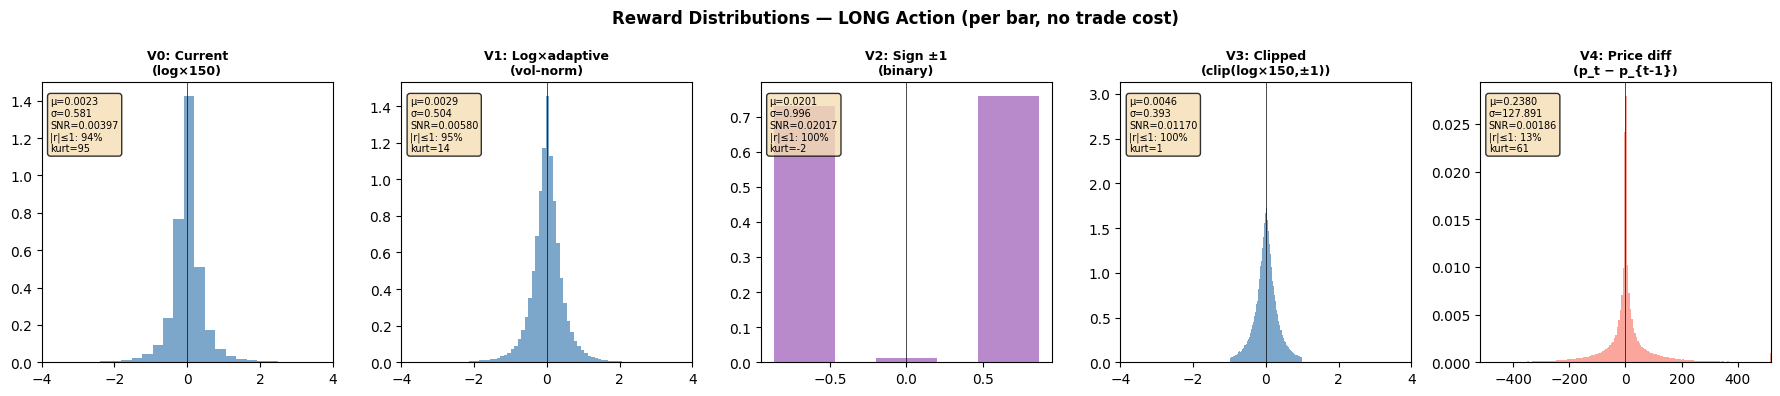

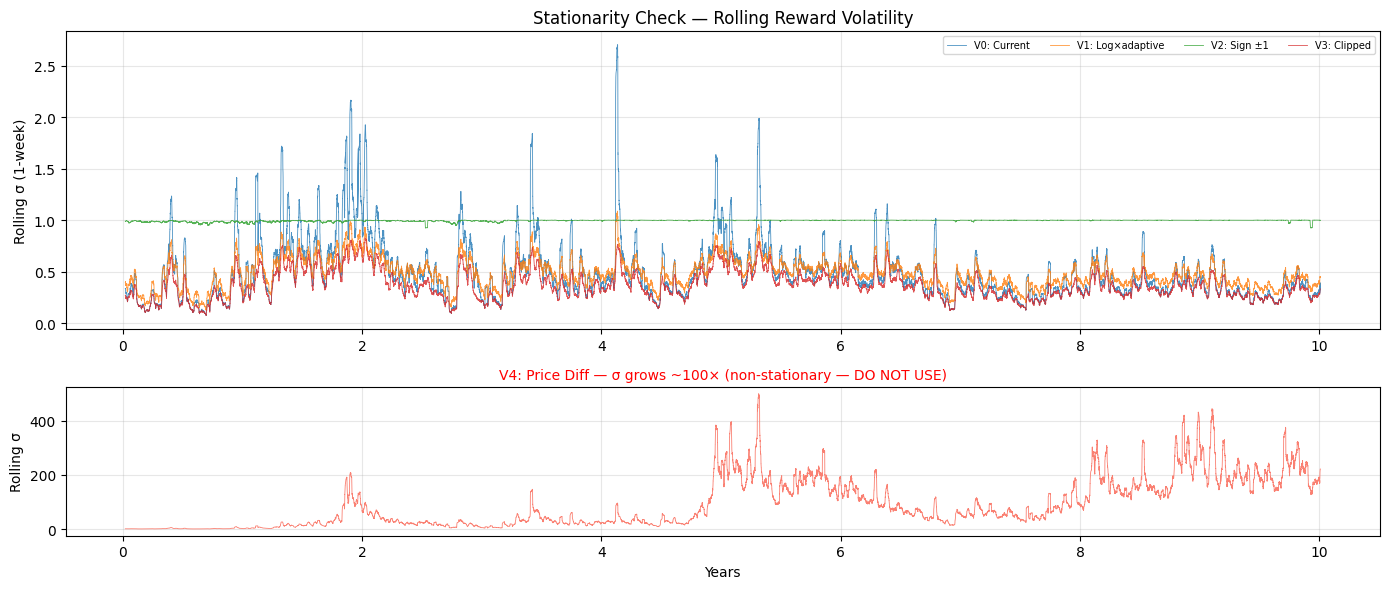

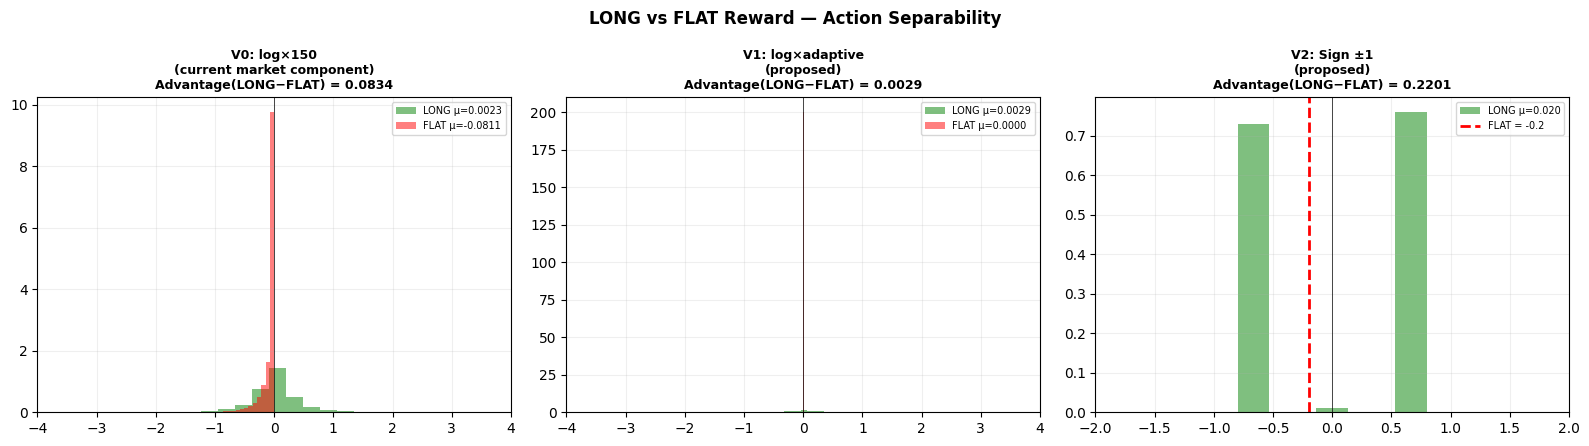


  REWARD VARIANT COMPARISON — SUMMARY
  Variant                    Mean      Std        SNR   |r|≤1   Kurt  σ ratio    Verdict
  ---------------------- -------- -------- ---------- ------- ------ -------- ----------
  V0: Current              0.0023    0.581   0.003969   94.2%     95    36.1×     REJECT
  V1: Log×adaptive         0.0029    0.504   0.005798   95.0%     14     8.7×         OK
  V2: Sign ±1              0.0201    0.996   0.020173  100.0%     -2     1.1×       GOOD
  V3: Clipped              0.0046    0.393   0.011701  100.0%      1    11.0×       GOOD
  V4: Price diff           0.2380  127.891   0.001861   13.0%     61  1761.0×     REJECT

  σ ratio = max(weekly_σ) / min(weekly_σ) — lower is more stationary
  Verdict: GOOD (stable + bounded), OK (usable), WEAK (poor bounds), REJECT (non-stationary)


In [27]:
# === SIMPLIFIED REWARD VARIANTS — COMPARISON ===

# --- Adaptive scale series ---
rolling_vol_96 = log_ret.rolling(96).std()
base_vol = log_ret.std()
vol_ratio_s = (rolling_vol_96 / base_vol).fillna(1.0).clip(0.2, 5.0)
adaptive_scale_s = SCALE / (0.5 + 0.5 * vol_ratio_s)

# --- Price diff ---
price_diff_s = df_clean['close'].diff()

# --- Common valid index ---
common_idx = (log_ret.dropna().index
              .intersection(adaptive_scale_s.dropna().index)
              .intersection(price_diff_s.dropna().index))
lr_v = log_ret.loc[common_idx].values
as_v = adaptive_scale_s.loc[common_idx].values
pd_v = price_diff_s.loc[common_idx].values

# === Define variants (LONG action, per bar, no trade cost) ===
V = {
    'V0: Current\n(log×150)':         lr_v * SCALE,
    'V1: Log×adaptive\n(vol-norm)':   lr_v * as_v,
    'V2: Sign ±1\n(binary)':         np.sign(lr_v).astype(float),
    'V3: Clipped\n(clip(log×150,±1))': np.clip(lr_v * SCALE, -1, 1),
    'V4: Price diff\n(p_t − p_{t-1})': pd_v,
}

# ====== FIGURE 1: Distributions ======
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for idx, (name, vals) in enumerate(V.items()):
    ax = axes[idx]
    is_price = 'Price' in name

    if is_price:
        clip_range = np.percentile(np.abs(vals), 99)
        ax.hist(np.clip(vals, -clip_range, clip_range), bins=200,
                density=True, alpha=0.7, color='salmon')
        ax.set_xlim(-clip_range, clip_range)
    elif 'Sign' in name:
        ax.hist(vals, bins=3, density=True, alpha=0.7, color='#9b59b6', rwidth=0.6)
    else:
        ax.hist(vals, bins=200, density=True, alpha=0.7, color='steelblue')
        ax.set_xlim(-4, 4)

    ax.axvline(0, color='black', lw=0.5)
    snr = abs(vals.mean()) / (vals.std() + 1e-10)
    pct1 = (np.abs(vals) <= 1).mean() * 100
    kurt = float(pd.Series(vals).kurtosis())

    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.text(0.03, 0.95,
            f'μ={vals.mean():.4f}\nσ={vals.std():.3f}\nSNR={snr:.5f}\n|r|≤1: {pct1:.0f}%\nkurt={kurt:.0f}',
            transform=ax.transAxes, fontsize=7, va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Reward Distributions — LONG Action (per bar, no trade cost)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ====== FIGURE 2: Stationarity — rolling std ======
fig, axes = plt.subplots(2, 1, figsize=(14, 6), gridspec_kw={'height_ratios': [2, 1]})
week_window = 96 * 7
x_yrs = np.arange(len(lr_v)) / (96 * 365)

ax = axes[0]
for name, vals in V.items():
    if 'Price' in name:
        continue
    rs = pd.Series(vals).rolling(week_window).std().values
    short = name.split('\n')[0]
    ax.plot(x_yrs, rs, lw=0.6, alpha=0.8, label=short)
ax.set_ylabel('Rolling σ (1-week)')
ax.set_title('Stationarity Check — Rolling Reward Volatility')
ax.legend(fontsize=7, ncol=4)
ax.grid(True, alpha=0.3)

ax = axes[1]
rs_pd = pd.Series(pd_v).rolling(week_window).std().values
ax.plot(x_yrs, rs_pd, lw=0.6, color='salmon')
ax.set_ylabel('Rolling σ')
ax.set_xlabel('Years')
ax.set_title('V4: Price Diff — σ grows ~100× (non-stationary — DO NOT USE)', fontsize=10, color='red')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ====== FIGURE 3: What the agent "sees" — LONG vs FLAT reward ======
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Three viable candidates side by side
candidates = {
    'V0: log×150\n(current market component)': (lr_v * SCALE, -np.maximum(lr_v * SCALE, 0) * OPP_COST_WEIGHT),
    'V1: log×adaptive\n(proposed)':             (lr_v * as_v, np.zeros_like(lr_v)),
    'V2: Sign ±1\n(proposed)':                  (np.sign(lr_v).astype(float), np.full_like(lr_v, -0.2)),
}

for idx, (name, (r_long, r_flat)) in enumerate(candidates.items()):
    ax = axes[idx]
    if 'Sign' in name:
        ax.hist(r_long, bins=3, density=True, alpha=0.5, color='green', label=f'LONG μ={r_long.mean():.3f}', rwidth=0.4)
        ax.axvline(r_flat[0], color='red', lw=2, ls='--', label=f'FLAT = {r_flat[0]:.1f}')
        ax.set_xlim(-2, 2)
    else:
        ax.hist(r_long, bins=200, density=True, alpha=0.5, color='green', label=f'LONG μ={r_long.mean():.4f}')
        ax.hist(r_flat, bins=200, density=True, alpha=0.5, color='red', label=f'FLAT μ={r_flat.mean():.4f}')
        ax.set_xlim(-4, 4)

    # Advantage: E[LONG] - E[FLAT]
    advantage = r_long.mean() - r_flat.mean()
    ax.set_title(f'{name}\nAdvantage(LONG−FLAT) = {advantage:.4f}', fontsize=9, fontweight='bold')
    ax.axvline(0, color='black', lw=0.5)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)

plt.suptitle('LONG vs FLAT Reward — Action Separability', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ====== SUMMARY TABLE ======
print("\n" + "=" * 95)
print("  REWARD VARIANT COMPARISON — SUMMARY")
print("=" * 95)
header = f"  {'Variant':<22} {'Mean':>8} {'Std':>8} {'SNR':>10} {'|r|≤1':>7} {'Kurt':>6} {'σ ratio':>8} {'Verdict':>10}"
print(header)
print(f"  {'-'*22} {'-'*8} {'-'*8} {'-'*10} {'-'*7} {'-'*6} {'-'*8} {'-'*10}")

for name, vals in V.items():
    short = name.split('\n')[0]
    snr = abs(vals.mean()) / (vals.std() + 1e-10)
    pct = (np.abs(vals) <= 1).mean() * 100
    kurt = float(pd.Series(vals).kurtosis())
    rs = pd.Series(vals).rolling(week_window).std().dropna()
    ratio = rs.max() / (rs.min() + 1e-10)

    if ratio > 20:
        verdict = "REJECT"
    elif pct < 50:
        verdict = "WEAK"
    elif snr > 0.01:
        verdict = "GOOD"
    else:
        verdict = "OK"

    print(f"  {short:<22} {vals.mean():>8.4f} {vals.std():>8.3f} {snr:>10.6f} {pct:>6.1f}% {kurt:>6.0f} {ratio:>7.1f}× {verdict:>10}")

print()
print("  σ ratio = max(weekly_σ) / min(weekly_σ) — lower is more stationary")
print("  Verdict: GOOD (stable + bounded), OK (usable), WEAK (poor bounds), REJECT (non-stationary)")

### Verdict: Which to test?

**Price diff (`p_t − p_{t-1}`) — REJECT immediately.**
BTC went from $381 to $84,000. A $1 move in 2016 is a 0.26% return; in 2026 it's 0.001%.
The reward σ grows ~100× over the dataset, making it impossible for the network to learn stable Q-values.
If you want "price change", normalize it: `(p_t − p_{t-1}) / p_{t-1}` — but that's just the simple return, which ≈ log return for 15-min bars (difference < 0.001%).

**Recommended test order (simplest first):**

| Priority | Variant | Why test it | FLAT reward |
|----------|---------|-------------|-------------|
| 1 | **Sign ±1** | Zero reward-shaping hyperparams. If the DQN can't learn direction, no reward function will help — this is your diagnostic baseline. | `−0.2` fixed |
| 2 | **Clipped linear** | Adds magnitude info within bounded range. Best of both worlds: informative but kurtosis-proof. | `0` |
| 3 | **Log × adaptive** | If V3/V4 show regime-dependent failures, this stabilizes the signal across vol regimes. | `0` |

**For all simplified variants:**
- Keep trade cost (`comm_frac × scale`) — it's real friction the agent must respect
- Drop DD penalty and opportunity cost initially
- If the agent defaults to always-FLAT with FLAT=0, add a small fixed penalty (−0.1 to −0.3)
- If the agent defaults to always-LONG, the trade cost isn't biting hard enough — increase it or add a small holding cost

**The Sign ±1 approach specifically:**
```python
def _generate_reward_sign(self, rewards):
    def _compute(re):
        p_t = 1.0 if re["action_private"] == self.ACTION_LONG else 0.0
        direction = 1.0 if re.get("market_log_return", 0.0) > 0 else -1.0
        trade_cost = re.get("comm_frac", 0.0) * 150  # keep trade cost real
        return p_t * direction - trade_cost + (1.0 - p_t) * (-0.2)
    return np.array([_compute(re) for re in rewards])
```
- LONG + market up → `+1.0`
- LONG + market down → `−1.0`
- FLAT (any market) → `−0.2`
- Entry/exit bar → subtract ~0.9 trade cost

The `−0.2` for FLAT means: over 5 bars of inaction, the agent accumulates `−1.0`, same as one wrong LONG call. This forces it to take positions rather than sit idle, while being much simpler than the opportunity cost mechanism.